# COMP3010 2026 Sem1 Machine Learning Final Assignment
## Author: Ethan Ty Riekert --- 22208187@student.curtin.edu.au

In this assignment, the main task is to perform a predictive analysis on the peak pressure generated by BLEVEs. Consider a scenario where a BLEVE occurs inside a rectangular tank located within a three-dimensional environment, positioned near a rigid obstacle (e.g a wall). The blast wave will interact with the obstable, producing reflections and complex pressure patterns that increase the complexity of the pressure distribution. The objective is to accurately predict the peak pressure in the vicinity of the obstacle.

The dataset includes:
- **27 sensors** (front, back, and side walls)  
- **Multiple physical and geometric input variables**, including:  
  - Tank dimensions  
  - Vapour/liquid temperatures  
  - Liquid ratio  
  - BLEVE height  
  - Obstacle geometry  
  - Sensor coordinates  
- **Target variable:** peak pressure (bar)

The provided files are:
- `train.csv` — includes all features + target pressure  
- `test.csv` — includes all features, target withheld  
- `sample_prediction.csv` — required output format  

The task is to:
1. Preprocess the data  
2. Develop and compare multiple ML models  
3. Generate final predictions for Kaggle submission  
4. Document the workflow in a report

#### Importing Base Modules For Program

In [7]:
import numpy as np # efficient vectors and tensors
import pandas as pd # data handling
import matplotlib.pyplot as plt # plots

# Neural Networks
import torch
import torch.nn as nn

## 1.0 Data Preprocessing
First we start with understanding the data we are dealing with, so that we can preprocess it

In [24]:
# Defining the route to data
route = "../Data/"

# Assigning the data to pandas dataframes
df_test = pd.read_csv(f"{route}test.csv")
df_train = pd.read_csv(f"{route}train.csv")
df_predictions = pd.read_csv(f"{route}sample_prediction.csv")

pd.set_option("display.precision", 2) # Don't need good precision for viewing data

### 1.1 Exploring the type of information held by each set

In [29]:
##       Exploring the type of information held by each set         ##
# Calculating Missing Values
missingVal_test = df_test.isnull().sum().sum()
missingVal_train = df_train.isnull().sum().sum()
missingVal_pred = df_predictions.isnull().sum().sum()

# Calculating Percentiles
# Probably could all be done in some list or loop
percentile = 0.98

num_test = df_test.select_dtypes(include='number')
num_train = df_train.select_dtypes(include='number')

thresholds_test = num_test.quantile(percentile)
thresholds_train = num_train.quantile(percentile)

over_test = (num_test > thresholds_test).sum()
over_train = (num_train > thresholds_train).sum()

# Checking for duplicate values
test_dup = df_test.duplicated().sum()
train_dup = df_train.duplicated().sum()
pred_dup = df_predictions.duplicated().sum()

# Checking correlation matrix for feature relations
test_corr = df_test.corr(numeric_only=True)
train_corr = df_train.corr(numeric_only=True)


#### 1.1.1 Checking the first (test) dataset

Missing values: 0
Duplicate values: 0
Shape: (3203, 24)
Dtypes: float64    15
int64       8
str         1
Name: count, dtype: int64


------
Amount outside 0.98% percentile: 
ID                                 65
Tank Failure Pressure (bar)        54
Liquid Ratio (%)                   54
Tank Width (m)                     27
Tank Length (m)                    54
Tank Height (m)                    27
BLEVE Height (m)                    0
Vapour Height (m)                  54
Vapour Temperature (K)             54
Liquid Temperature (K)             54
Obstacle Distance to BLEVE (m)      0
Obstacle Width (m)                 54
Obstacle Height (m)                54
Obstacle Thickness (m)              0
Obstacle Angle                      0
Liquid Critical Pressure (bar)      0
Liquid Boiling Temperature (K)      0
Liquid Critical Temperature (K)     0
Sensor ID                           0
Sensor Position Side                0
Sensor Position x                  54
Sensor Position y          

,ID,Tank Failure Pressure (bar),Liquid Ratio (%),Tank Width (m),Tank Length (m),Tank Height (m),BLEVE Height (m),Vapour Height (m),Vapour Temperature (K),Liquid Temperature (K),...,Obstacle Thickness (m),Obstacle Angle,Liquid Critical Pressure (bar),Liquid Boiling Temperature (K),Liquid Critical Temperature (K),Sensor ID,Sensor Position Side,Sensor Position x,Sensor Position y,Sensor Position z
count,3203.00,3203.00,3203.00,3203.00,3203.00,3203.00,3203.00,3203.00,3203.00,3203.00,...,3203.00,3203.00,3203.00,3203.00,3203.00,3203.00,3203.00,3203.00,3203.00,3203.00
mean,1601.00,21.31,0.49,1.77,5.13,1.57,1.04,0.83,402.83,342.69,...,1.70,13.79,40.11,-20.70,125.43,13.97,2.33,13.02,2.90,3.38
std,924.77,10.12,0.22,0.74,2.55,0.70,0.57,0.53,73.49,37.19,...,0.79,9.02,2.30,20.49,27.63,7.79,1.33,4.34,4.50,4.47
min,0.00,5.10,0.10,0.40,0.60,0.40,0.00,0.20,292.60,283.10,...,0.40,0.00,37.90,-42.00,96.70,1.00,1.00,5.15,-6.85,-2.90
25%,800.50,13.20,0.28,1.00,3.20,1.00,0.60,0.40,341.60,313.10,...,1.00,6.00,37.90,-42.00,96.70,7.00,1.00,9.35,0.15,-0.60
50%,1601.00,20.60,0.50,1.80,4.60,1.40,1.00,0.60,391.90,340.50,...,1.80,13.00,37.90,-1.00,152.00,14.00,2.00,12.60,2.85,2.50
75%,2401.50,30.70,0.68,2.40,7.40,2.20,1.60,1.20,438.80,368.80,...,2.40,22.00,42.50,-1.00,152.00,21.00,3.00,16.38,6.10,6.10
max,3202.00,42.00,0.88,3.00,9.80,3.00,2.00,2.40,571.80,424.40,...,3.00,30.00,42.50,-1.00,152.00,27.00,5.00,22.95,17.25,16.50


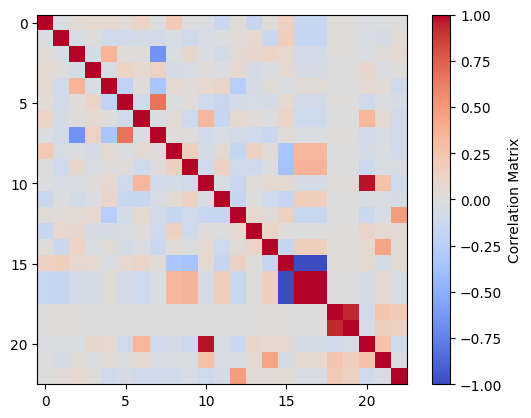

In [ ]:
# NTS: We have no need to see the .head() as we have the .csv downloaded permanently. Can check that
print(f"Missing values: {missingVal_test}")
print(f"Duplicate values: {test_dup}")
print(f"Shape: {df_test.shape}")
print(f"Dtypes: \n{df_test.dtypes.value_counts()}\n\n")
print(f"------\nAmount outside {percentile}% percentile: \n{over_test}\n-----")


plt.figure()
plt.imshow(test_corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='Correlation Matrix')

df_test.describe()

##### Analysis
We have no duplicate or missing values that we have to take care of. However, there are some values that exist outside the $98\%$ percentile that we have to take care of. Moreover, there is one categorical column we have to encode

#### 1.1.2 Checking the second (train) dataset

In [ ]:
print(f"Missing values {df_train.isnull().sum().sum()}")
print(df_train.shape)
print(df_train.info())
df_train.describe()

,ID,Tank Failure Pressure (bar),Liquid Ratio (%),Tank Width (m),Tank Length (m),Tank Height (m),BLEVE Height (m),Vapour Height (m),Vapour Temperature (K),Liquid Temperature (K),...,Status,Liquid Critical Pressure (bar),Liquid Boiling Temperature (K),Liquid Critical Temperature (K),Sensor ID,Sensor Position Side,Sensor Position x,Sensor Position y,Sensor Position z,Target Pressure (bar)
0,3203.0,7.32,0.42,2.42,5.39,1.00,1.79,0.60,524.61,354.49,...,Superheated,37.9,-1.0,152.0,18.0,2.0,12.15,7.90,10.7,0.199929
1,3204.0,7.18,0.42,2.39,5.39,1.01,1.81,0.59,522.80,354.31,...,Superheated,37.9,-1.0,152.0,19.0,3.0,12.50,-2.95,-1.9,0.435681
2,3205.0,7.32,0.41,2.39,5.38,1.00,1.78,0.62,523.00,354.59,...,Superheated,37.9,-1.0,152.0,20.0,3.0,12.50,-2.95,4.4,0.264031
3,3206.0,7.26,0.42,2.40,5.41,1.00,1.81,0.61,522.35,354.37,...,Superheated,37.9,-1.0,152.0,21.0,3.0,12.50,-2.95,10.7,0.270576
4,3207.0,7.32,0.42,2.40,5.41,1.02,1.79,0.62,522.98,354.33,...,Superheated,37.9,-1.0,152.0,22.0,4.0,12.50,-2.70,11.0,0.204675


#### 1.1.3 Checking the third (predictions) dataset

In [ ]:
print(f"Missing values {df_predictions.isnull().sum().sum()}")
print(df_predictions.shape)
print(df_predictions.info())
df_predictions.describe()

,ID,Target Pressure (bar)
0,0,0.944502
1,1,0.506173
2,2,0.306880
3,3,0.027756
4,4,0.384144


#### 1.1.4 Sanity checks

In [27]:
assert len(df_predictions) == len(df_test)

### 1.2 Handling Missing Values

Note to self: Busy doing analysis of the first dataset however I have just learnt that you don't really need to analyse the testing set.